# Remove Consumption Factors and Reallocate Fundamental Weights

This research version removes `sig_consumption_growth` and `sig_consumption_mom`. The original fundamental composite had 11 equal internal slots, each worth $1/11$. After removing both consumption slots, their two fixed allocations are assigned to the remaining nine factors.

Weights are selected using only the July 2017–December 2020 development period: first retain candidates within 0.01 Sharpe of the development maximum, then choose the lowest-turnover candidate. The 2021–2023 validation period and 2024–2026 holdout do not participate in selection. Weather, wind, solar, top-level fundamental allocation, the five-session early roll, and the 2.5 bps cost all remain unchanged.

In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'naturalgas').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from naturalgas.evaluate_no_consumption_fundamental_weights import (
    DEFAULT_OUTPUT_DIR, LOCAL_PANEL, SOLAR_LEAD_PATH, SOLAR_SIGNAL_PATH,
    STRATEGY_START, THROUGH_DATE, WIND_FEATURES, run,
)

OUTPUT_DIR = DEFAULT_OUTPUT_DIR
RUN_BACKTEST = True
if RUN_BACKTEST:
    summary = run(
        panel_path=LOCAL_PANEL, wind_path=WIND_FEATURES,
        solar_signal_path=SOLAR_SIGNAL_PATH, solar_lead_path=SOLAR_LEAD_PATH,
        output_dir=OUTPUT_DIR, start=STRATEGY_START, through_date=THROUGH_DATE,
    )
else:
    summary = json.loads((OUTPUT_DIR / 'summary.json').read_text())
summary['selected_candidate']

'reallocate__low_storage__lng_export_mom'

## Final internal fundamental weights

`original_weight` is the original $1/11$ allocation per component. `selected_weight` is the fixed allocation after removing both consumption components and reallocating their slots.

In [2]:
weights = pd.read_csv(OUTPUT_DIR / 'selected_weights.csv')
weights.assign(
    original_pct=100 * weights['original_weight'],
    selected_pct=100 * weights['selected_weight'],
    change_pct=100 * weights['weight_change'],
)[[
    'component', 'removed', 'original_pct', 'selected_pct', 'change_pct'
]].round(2)

,component,removed,original_pct,selected_pct,change_pct
0,sig_low_storage,False,9.09,18.18,9.09
1,sig_storage_change,False,9.09,9.09,0.00
2,sig_storage_4w_change,False,9.09,9.09,0.00
3,sig_low_production_growth,False,9.09,9.09,0.00
4,sig_lng_export_growth,False,9.09,9.09,0.00
5,sig_consumption_growth,True,9.09,0.00,-9.09
6,sig_net_import_supply,False,9.09,9.09,0.00
7,sig_production_mom,False,9.09,9.09,0.00
8,sig_lng_export_mom,False,9.09,18.18,9.09
9,sig_consumption_mom,True,9.09,0.00,-9.09


## Development, validation, and holdout comparison

The three rows are the original equal-weight 11-factor version, an equal-weight nine-factor version after removing consumption, and the two-slot reallocation selected only on development. Emphasis should be on validation and holdout rather than the full sample.

In [3]:
periods = pd.read_csv(OUTPUT_DIR / 'period_comparison.csv')
period_table = periods.pivot_table(
    index='candidate', columns='period',
    values=['sharpe_zero_rf', 'cagr', 'annualized_volatility', 'maximum_drawdown'],
)
period_table.round(4)

annualized_volatility  \
period                                            development   
candidate                                                       
current_all_11_equal                                   0.0567   
no_consumption_equal_9                                 0.0694   
reallocate__low_storage__lng_export_mom                0.0662   

                                                                               \
period                                  first_look_holdout    full validation   
candidate                                                                       
current_all_11_equal                                0.0746  0.0692     0.0775   
no_consumption_equal_9                              0.0890  0.0820     0.0894   
reallocate__low_storage__lng_export_mom             0.0892  0.0809     0.0890   

                                               cagr                     \
period                                  development first_look_holdout   
candidate                                                                
current_all_11_equal                         0.1132             0.1036   
no_consumption_equal_9                       0.1183             0.1241   
reallocate__low_storage__lng_export_mom      0.1195             0.1324   

                                                           maximum_drawdown  \
period                                     full validation      development   
candidate                                                                     
current_all_11_equal                     0.1221     0.1496          -0.0351   
no_consumption_equal_9                   0.1359     0.1682          -0.0458   
reallocate__low_storage__lng_export_mom  0.1408     0.1749          -0.0388   

                                                                               \
period                                  first_look_holdout    full validation   
candidate                                                                       
current_all_11_equal                               -0.0567 -0.0567    -0.0444   
no_consumption_equal_9                             -0.0570 -0.0570    -0.0460   
reallocate__low_storage__lng_export_mom            -0.0562 -0.0562    -0.0498   

                                        sharpe_zero_rf                     \
period                                     development first_look_holdout   
candidate                                                                   
current_all_11_equal                            1.8859             1.3265   
no_consumption_equal_9                          1.6057             1.3203   
reallocate__low_storage__lng_export_mom         1.6999             1.3993   

                                                            
period                                     full validation  
candidate                                                   
current_all_11_equal                     1.6682     1.8002  
no_consumption_equal_9                   1.5574     1.7405  
reallocate__low_storage__lng_export_mom  1.6326     1.8124

In [4]:
annual = pd.read_csv(OUTPUT_DIR / 'annual_comparison.csv')
annual.pivot(index='year', columns='candidate', values='sharpe_zero_rf').round(3)

candidate,current_all_11_equal,no_consumption_equal_9,reallocate__low_storage__lng_export_mom
year,,,
2017,2.011,1.488,1.359
2018,-0.156,-0.052,0.014
2019,2.436,1.988,2.082
2020,2.714,2.295,2.503
2021,1.601,1.791,1.793
2022,2.849,2.598,2.747
2023,0.637,0.722,0.812
2024,2.568,2.544,2.605
2025,-0.475,-0.489,-0.502


## Cumulative net wealth

All curves use identical trading dates, return series, and a 2.5 bps one-way turnover cost.

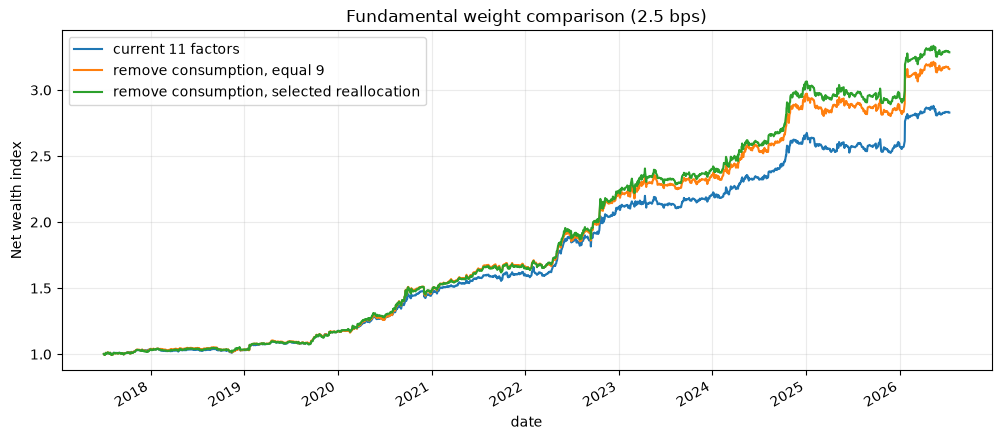

In [5]:
daily = pd.read_parquet(OUTPUT_DIR / 'selected_daily.parquet')
daily = daily.set_index('date')
ax = daily[[
    'net_index_current', 'net_index_equal_9', 'net_index_selected'
]].rename(columns={
    'net_index_current': 'current 11 factors',
    'net_index_equal_9': 'remove consumption, equal 9',
    'net_index_selected': 'remove consumption, selected reallocation',
}).plot(figsize=(12, 5), title='Fundamental weight comparison (2.5 bps)')
ax.set_ylabel('Net wealth index')
ax.grid(alpha=0.25)
plt.show()

## Research judgment

Removing consumption is a structural decision about publication lag and economic interpretability; it cannot be justified by full-sample Sharpe alone. If the reallocated version does not outperform the original in holdout, it should remain a research candidate rather than automatically replacing the formal strategy.

In [6]:
sharpes = periods.pivot(index='candidate', columns='period', values='sharpe_zero_rf')
sharpes.round(4)

period,development,first_look_holdout,full,validation
candidate,,,,
current_all_11_equal,1.8859,1.3265,1.6682,1.8002
no_consumption_equal_9,1.6057,1.3203,1.5574,1.7405
reallocate__low_storage__lng_export_mom,1.6999,1.3993,1.6326,1.8124


In [7]:
# Exploratory upper bound: pretend final month-M production/consumption data are known in month M.
# This is deliberately look-ahead and must never be interpreted as a tradable backtest.
import gcsfs
import numpy as np

from naturalgas.evaluate_native_frequency_fundamentals import (
    apply_native_frequency_fundamentals, causal_z,
)
from naturalgas.evaluate_no_consumption_fundamental_weights import (
    candidate_position, common_sample_mask, metrics_for, prepare_base_panel,
    transform_components, weighted_available,
)
from naturalgas.evaluate_ncar_gdex_complete_solar_factor import (
    load_capacity_weighted_solar,
)

filesystem = gcsfs.GCSFileSystem()
panel_pi = pd.read_parquet(LOCAL_PANEL)
panel_pi['date'] = pd.to_datetime(panel_pi['date']).astype('datetime64[ns]')
native_pi = apply_native_frequency_fundamentals(panel_pi, filesystem)
solar_pi = load_capacity_weighted_solar(SOLAR_SIGNAL_PATH, SOLAR_LEAD_PATH)
base_pi = prepare_base_panel(native_pi, wind_path=WIND_FEATURES, solar=solar_pi)
transformed_pi = transform_components(base_pi)

with filesystem.open(
    'bcli-natgas-data-497807/processed/fundamentals_monthly.parquet', 'rb'
) as handle:
    monthly_pi = pd.read_parquet(handle)
monthly_pi = monthly_pi.sort_values('month').copy()
monthly_pi['month'] = pd.to_datetime(monthly_pi['month'])
month_days = monthly_pi['month'].dt.days_in_month
monthly_pi['prod_yoy_raw'] = (
    monthly_pi['dry_prod'] / monthly_pi['dry_prod'].shift(12) - 1.0
)
monthly_pi['cons_yoy_raw'] = (
    monthly_pi['total_cons'] / monthly_pi['total_cons'].shift(12) - 1.0
)
production_daily_rate = monthly_pi['dry_prod'] / month_days
monthly_pi['prod_mom_raw'] = (
    production_daily_rate / production_daily_rate.shift(1) - 1.0
)
monthly_pi['pi_low_production_yoy'] = -causal_z(
    monthly_pi['prod_yoy_raw'], window=60, min_periods=36,
)
monthly_pi['pi_production_mom'] = -causal_z(
    monthly_pi['prod_mom_raw'], window=60, min_periods=36,
)
monthly_pi['pi_consumption_yoy'] = causal_z(
    monthly_pi['cons_yoy_raw'], window=60, min_periods=36,
)
monthly_pi['period'] = monthly_pi['month'].dt.to_period('M')

# Remove the normal M+3 availability rule only for this explanatory upper bound.
aligned_pi = pd.DataFrame({'period': base_pi['date'].dt.to_period('M')}).merge(
    monthly_pi[[
        'period', 'pi_low_production_yoy', 'pi_production_mom',
        'pi_consumption_yoy',
    ]],
    on='period', how='left', validate='many_to_one',
)
perfect_transformed = transformed_pi.copy()
perfect_transformed['sig_low_production_growth'] = np.tanh(
    aligned_pi['pi_low_production_yoy'].to_numpy() / 2.0
)
perfect_transformed['sig_production_mom'] = (
    aligned_pi['pi_production_mom'].to_numpy()
)
perfect_transformed['sig_consumption_growth'] = np.tanh(
    aligned_pi['pi_consumption_yoy'].to_numpy() / 2.0
)

baseline_weights = {
    key: float(value) for key, value in summary['selected_weights'].items()
}
production_weights = baseline_weights.copy()
# Restore one fixed 1/11 consumption-YoY slot without optimizing a new weight.
# Fund it symmetrically from the two previously doubled slots.
prod_cons_weights = baseline_weights.copy()
prod_cons_weights['sig_low_storage'] -= 0.5 / 11.0
prod_cons_weights['sig_lng_export_mom'] -= 0.5 / 11.0
prod_cons_weights['sig_consumption_growth'] = 1.0 / 11.0
assert np.isclose(sum(prod_cons_weights.values()), 1.0)

fundamental_pi = {
    'baseline_real_release': weighted_available(
        transformed_pi, baseline_weights,
    ),
    'perfect_info_production': weighted_available(
        perfect_transformed, production_weights,
    ),
    'perfect_info_prod_plus_cons_yoy': weighted_available(
        perfect_transformed, prod_cons_weights,
    ),
}
score_position_pi = {
    name: candidate_position(base_pi, values)
    for name, values in fundamental_pi.items()
}
positions_pi = {name: pair[1] for name, pair in score_position_pi.items()}
common_pi = common_sample_mask(
    base_pi, positions_pi, start=STRATEGY_START, end=THROUGH_DATE,
)
period_definitions_pi = {
    'development': (STRATEGY_START, pd.Timestamp('2020-12-31')),
    'validation': (pd.Timestamp('2021-01-01'), pd.Timestamp('2023-12-31')),
    'first_look_holdout': (pd.Timestamp('2024-01-01'), THROUGH_DATE),
    'full': (STRATEGY_START, THROUGH_DATE),
}
rows_pi = []
for period_name, (period_start, period_end) in period_definitions_pi.items():
    period_mask = common_pi & base_pi['date'].between(period_start, period_end)
    for candidate_name, candidate_position_values in positions_pi.items():
        row = metrics_for(
            base_pi, candidate_position_values, period_mask,
        )
        row.update({'period': period_name, 'candidate': candidate_name})
        rows_pi.append(row)
perfect_info_results = pd.DataFrame(rows_pi)
print(
    'WARNING: perfect-information / explanatory test only. Final month-M EIA '
    'values are aligned to month M and were not actually tradable then.'
)
print(
    'Consumption MoM is excluded. No weight or parameter was selected on '
    'validation/holdout.'
)
display(
    perfect_info_results.pivot_table(
        index='period', columns='candidate',
        values=['sharpe_zero_rf', 'cagr', 'maximum_drawdown'],
    ).reindex(period_definitions_pi).round(4)
)

Consumption MoM is excluded. No weight or parameter was selected on validation/holdout.


metric                           cagr                    maximum_drawdown                    sharpe_zero_rf                                     
candidate       baseline_real_release perfect_info_prod_plus_cons_yoy perfect_info_production baseline_real_release perfect_info_prod_plus_cons_yoy perfect_info_production baseline_real_release perfect_info_prod_plus_cons_yoy perfect_info_production
period                                                                                                                                                                                                                                                                
development                   0.1195                          0.1014                  0.0927               -0.0388                         -0.0476                 -0.0575                1.6999                          1.3876                   1.2724
validation                    0.1749                          0.1906                  0.2009

In [8]:
# Extension of the perfect-information upper bound: remove M+3 for both LNG factors.
from naturalgas.evaluate_native_frequency_fundamentals import LNG_TRADE_KEY

with filesystem.open(LNG_TRADE_KEY, 'rb') as handle:
    lng_pi = pd.read_parquet(handle)
lng_pi = lng_pi.loc[
    lng_pi['dataset'].eq('country_exports')
    & lng_pi['is_us_aggregate'].fillna(False)
    & lng_pi['process-name'].eq('Liquefied Natural Gas Exports')
    & lng_pi['metric'].eq('volume'),
    ['month', 'value'],
].rename(columns={'value': 'lng_exports'}).sort_values('month')
lng_pi['month'] = pd.to_datetime(lng_pi['month'])
lng_days = lng_pi['month'].dt.days_in_month
lng_pi['lng_yoy_raw'] = (
    lng_pi['lng_exports'] / lng_pi['lng_exports'].shift(12) - 1.0
)
lng_daily_rate = lng_pi['lng_exports'] / lng_days
lng_pi['lng_mom_raw'] = (
    lng_daily_rate / lng_daily_rate.shift(1) - 1.0
)
lng_pi['pi_lng_yoy'] = causal_z(
    lng_pi['lng_yoy_raw'], window=60, min_periods=36,
)
lng_pi['pi_lng_mom'] = causal_z(
    lng_pi['lng_mom_raw'], window=60, min_periods=36,
)
lng_pi['period'] = lng_pi['month'].dt.to_period('M')
aligned_lng_pi = pd.DataFrame({
    'period': base_pi['date'].dt.to_period('M'),
}).merge(
    lng_pi[['period', 'pi_lng_yoy', 'pi_lng_mom']],
    on='period', how='left', validate='many_to_one',
)

# Audit: shifting the reconstruction to M+3 must exactly reproduce current inputs.
lng_audit = lng_pi.assign(available_period=lng_pi['period'] + 3)
current_lng_audit = pd.DataFrame({
    'period': base_pi['date'].dt.to_period('M'),
    'existing_yoy': base_pi['sig_lng_export_growth'],
    'existing_mom': base_pi['sig_lng_export_mom'],
}).merge(
    lng_audit[['available_period', 'pi_lng_yoy', 'pi_lng_mom']],
    left_on='period', right_on='available_period', how='left',
)
for existing_column, rebuilt_column in (
    ('existing_yoy', 'pi_lng_yoy'), ('existing_mom', 'pi_lng_mom'),
):
    audit_rows = current_lng_audit[[existing_column, rebuilt_column]].dropna()
    assert np.allclose(
        audit_rows[existing_column], audit_rows[rebuilt_column], atol=1e-12,
    )

perfect_lng_transformed = transformed_pi.copy()
perfect_lng_transformed['sig_lng_export_growth'] = np.tanh(
    aligned_lng_pi['pi_lng_yoy'].to_numpy() / 2.0
)
perfect_lng_transformed['sig_lng_export_mom'] = (
    aligned_lng_pi['pi_lng_mom'].to_numpy()
)
perfect_all_transformed = perfect_transformed.copy()
perfect_all_transformed['sig_lng_export_growth'] = (
    perfect_lng_transformed['sig_lng_export_growth']
)
perfect_all_transformed['sig_lng_export_mom'] = (
    perfect_lng_transformed['sig_lng_export_mom']
)

fundamental_lng_pi = {
    'baseline_real_release': fundamental_pi['baseline_real_release'],
    'perfect_info_lng': weighted_available(
        perfect_lng_transformed, baseline_weights,
    ),
    'perfect_info_prod_plus_cons_yoy': (
        fundamental_pi['perfect_info_prod_plus_cons_yoy']
    ),
    'perfect_info_all_retained': weighted_available(
        perfect_all_transformed, prod_cons_weights,
    ),
}
positions_lng_pi = {
    name: candidate_position(base_pi, values)[1]
    for name, values in fundamental_lng_pi.items()
}
common_lng_pi = common_sample_mask(
    base_pi, positions_lng_pi, start=STRATEGY_START, end=THROUGH_DATE,
)
rows_lng_pi = []
for period_name, (period_start, period_end) in period_definitions_pi.items():
    period_mask = (
        common_lng_pi & base_pi['date'].between(period_start, period_end)
    )
    for candidate_name, candidate_position_values in positions_lng_pi.items():
        row = metrics_for(base_pi, candidate_position_values, period_mask)
        row.update({'period': period_name, 'candidate': candidate_name})
        rows_lng_pi.append(row)
perfect_info_lng_results = pd.DataFrame(rows_lng_pi)
print(
    'WARNING: perfect-information extension. Final month-M LNG export values '
    'are aligned to month M.'
)
print(
    'LNG reconstruction validation: exact match to both currently lagged '
    'factors after applying M+3.'
)
display(
    perfect_info_lng_results.pivot_table(
        index='period', columns='candidate',
        values=['sharpe_zero_rf', 'cagr', 'maximum_drawdown'],
    ).reindex(period_definitions_pi).round(4)
)

LNG reconstruction validation: exact match to both currently lagged factors after applying M+3.


metric                           cagr                    maximum_drawdown                    sharpe_zero_rf                                     
candidate       baseline_real_release perfect_info_all_retained perfect_info_lng perfect_info_prod_plus_cons_yoy baseline_real_release perfect_info_all_retained perfect_info_lng perfect_info_prod_plus_cons_yoy baseline_real_release perfect_info_all_retained perfect_info_lng perfect_info_prod_plus_cons_yoy
period                                                                                                                                                                                                                                                                                                                     
development                   0.1195                    0.1008           0.1191                          0.1014               -0.0388                   -0.0476          -0.0386                         -0.0476                1.6999  

In [9]:
# Robustness test: every fundamental component uses tanh(z / 2).
# This adds compression to production MoM, LNG MoM and net-import change,
# which previously retained raw z-scores. Consumption MoM remains excluded.
from naturalgas.evaluate_no_consumption_fundamental_weights import ALL_COMPONENTS

all_tanh_real = pd.DataFrame(index=base_pi.index)
for component in ALL_COMPONENTS:
    all_tanh_real[component] = np.tanh(
        pd.to_numeric(base_pi[component], errors='coerce') / 2.0
    )

all_tanh_prod_cons = all_tanh_real.copy()
all_tanh_prod_cons['sig_low_production_growth'] = np.tanh(
    aligned_pi['pi_low_production_yoy'].to_numpy() / 2.0
)
all_tanh_prod_cons['sig_production_mom'] = np.tanh(
    aligned_pi['pi_production_mom'].to_numpy() / 2.0
)
all_tanh_prod_cons['sig_consumption_growth'] = np.tanh(
    aligned_pi['pi_consumption_yoy'].to_numpy() / 2.0
)
all_tanh_lng = all_tanh_real.copy()
all_tanh_lng['sig_lng_export_growth'] = np.tanh(
    aligned_lng_pi['pi_lng_yoy'].to_numpy() / 2.0
)
all_tanh_lng['sig_lng_export_mom'] = np.tanh(
    aligned_lng_pi['pi_lng_mom'].to_numpy() / 2.0
)
all_tanh_all = all_tanh_prod_cons.copy()
all_tanh_all['sig_lng_export_growth'] = all_tanh_lng[
    'sig_lng_export_growth'
]
all_tanh_all['sig_lng_export_mom'] = all_tanh_lng['sig_lng_export_mom']

all_tanh_fundamentals = {
    'official_mixed': fundamental_pi['baseline_real_release'],
    'all_tanh_real': weighted_available(all_tanh_real, baseline_weights),
    'all_tanh_pi_production': weighted_available(
        all_tanh_prod_cons, baseline_weights,
    ),
    'all_tanh_pi_prod_cons_yoy': weighted_available(
        all_tanh_prod_cons, prod_cons_weights,
    ),
    'all_tanh_pi_lng': weighted_available(all_tanh_lng, baseline_weights),
    'all_tanh_pi_all': weighted_available(all_tanh_all, prod_cons_weights),
}
all_tanh_positions = {
    name: candidate_position(base_pi, values)[1]
    for name, values in all_tanh_fundamentals.items()
}
all_tanh_common = common_sample_mask(
    base_pi, all_tanh_positions, start=STRATEGY_START, end=THROUGH_DATE,
)
all_tanh_rows = []
for period_name, (period_start, period_end) in period_definitions_pi.items():
    period_mask = (
        all_tanh_common
        & base_pi['date'].between(period_start, period_end)
    )
    for candidate_name, candidate_position_values in all_tanh_positions.items():
        row = metrics_for(base_pi, candidate_position_values, period_mask)
        row.update({'period': period_name, 'candidate': candidate_name})
        all_tanh_rows.append(row)
all_tanh_results = pd.DataFrame(all_tanh_rows)
candidate_order_tanh = list(all_tanh_fundamentals)
print(
    'All fundamental components use tanh(z/2); consumption MoM remains '
    'excluded by weight.'
)
print(
    'Candidates containing pi are still perfect-information upper bounds.'
)
display(
    all_tanh_results.pivot(
        index='period', columns='candidate', values='sharpe_zero_rf',
    ).reindex(
        index=period_definitions_pi, columns=candidate_order_tanh,
    ).round(4)
)
full_tanh_metrics = all_tanh_results.loc[
    all_tanh_results['period'].eq('full')
].set_index('candidate')
display(
    full_tanh_metrics.loc[
        ['official_mixed', 'all_tanh_real', 'all_tanh_pi_all'],
        [
            'sharpe_zero_rf', 'cagr', 'maximum_drawdown',
            'total_return', 'total_turnover',
        ],
    ].T.round(4)
)

All fundamental components use tanh(z/2); consumption MoM remains excluded by weight.
Candidates containing pi are still perfect-information upper bounds.


candidate          official_mixed  all_tanh_real  all_tanh_pi_production  all_tanh_pi_prod_cons_yoy  all_tanh_pi_lng  all_tanh_pi_all
period                                                                                                                                    
development               1.6999         1.7570                  1.6590                     1.7997           1.7638           1.7982
validation                1.8124         1.8789                  1.9253                     1.8713           1.8996           1.8814
first_look_holdout         1.3993         1.3539                  1.5251                     1.5631           1.3847           1.5623
full                      1.6326         1.6538                  1.6930                     1.7291           1.6757           1.7328

candidate          official_mixed  all_tanh_real  all_tanh_pi_all
metric                                                                    
sharpe_zero_rf             1.6326         1.6538              1.7328
cagr                       0.1408         0.1235              0.1290
maximum_drawdown          -0.0562        -0.0461             -0.0444
total_return               2.2854         1.8613              1.9904
total_turnover           149.8006       147.3993            146.9642